# Fase 8a — Interpretabilidad SHAP (CatBoost)

Explicabilidad global y local del modelo principal (CatBoost+Optuna) sobre el test temporal de MIMIC-IV-ED.

**Figuras generadas:**
- `shap_summary_L{1,2,3}.png` — beeswarm plot (distribución de SHAP values por feature)
- `shap_bar_L{1,2,3}.png` — importancia global (media |SHAP|)
- `shap_waterfall_L{1,2,3}.png` — explicación local: caso de mayor y menor riesgo

SHAP (SHapley Additive exPlanations) asigna a cada feature una contribución aditiva al output del modelo, con propiedades de consistencia y eficiencia demostradas por Lundberg & Lee (2017). Se usa TreeExplainer, exacto para modelos de árbol, sobre una muestra aleatoria de 5.000 casos del test.

**Referencia:** Lundberg & Lee (2017). *A unified approach to interpreting model predictions.* NeurIPS.

In [1]:
import logging, sys
from pathlib import Path

_root = Path("../..").resolve()

logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s', force=True)
print(f'Raíz: {_root}')

Raíz: C:\Users\cuent\Desktop\TFM


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from catboost import CatBoostClassifier

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.size'         : 9,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'savefig.facecolor' : 'white',
    'text.color'        : 'black',
    'axes.labelcolor'   : 'black',
    'xtick.color'       : 'black',
    'ytick.color'       : 'black',
    'axes.edgecolor'    : 'black',
})

PROCESSED  = _root / 'data' / 'processed'
MODELS_DIR = _root  / 'models'
FIG        = _root  / 'reports' / 'figures'
TAB        = _root  / 'reports' / 'tables'

TARGETS  = ['L1', 'L2', 'L3']
CB_DIR   = MODELS_DIR / 'catboost_optuna' / '20260609_224204'

NUM_FEATURES = ['temperature', 'heartrate', 'resprate', 'o2sat',
                'sbp', 'dbp', 'acuity', 'n_medications', 'pain']
CB_FEATURES  = NUM_FEATURES + ['chiefcomplaint', 'arrival_transport']

FEAT_LABELS     = ['Temperatura', 'Frec. cardíaca', 'Frec. respiratoria', 'SpO₂',
                   'TAS', 'TAD', 'Acuity (ESI)', 'N.º fármacos', 'Dolor']
FEAT_LABELS_ALL = FEAT_LABELS + ['Chief complaint', 'Modo llegada']

TARGET_NAMES = {'L1': 'Ingreso hospitalario', 'L2': 'Mortalidad/Crítico', 'L3': 'Intervención crítica'}

print(f'MODELS_DIR: {MODELS_DIR}')
print(f'PROCESSED:  {PROCESSED}')

MODELS_DIR: C:\Users\cuent\Desktop\TFM\models
PROCESSED:  C:\Users\cuent\Desktop\TFM\data\processed


## 1. Cargar datos y muestra

Se carga el set de test completo y se extrae una muestra aleatoria de 5.000 casos para el cálculo de SHAP values. TreeExplainer es exacto para modelos de árbol; la muestra reduce el tiempo de cómputo sin pérdida significativa de representatividad.

In [3]:
df_test = pd.read_parquet(PROCESSED / 'test.parquet')
n_meds  = pd.read_parquet(PROCESSED / 'medrecon_nmeds.parquet')
df_test = df_test.merge(n_meds[['stay_id', 'n_medications']], on='stay_id', how='left')
df_test['n_medications']  = df_test['n_medications'].fillna(0).astype(float)
df_test['pain']           = pd.to_numeric(df_test['pain'], errors='coerce')
df_test['chiefcomplaint'] = df_test['chiefcomplaint'].fillna('').astype(str).str.lower().str.strip()
# arrival_transport en minúsculas para coincidir con el entrenamiento de CatBoost
df_test['arrival_transport'] = df_test['arrival_transport'].fillna('unknown').astype(str).str.lower().str.strip()

X_test     = df_test[CB_FEATURES]
N_SAMPLE   = 5000
sample_idx = np.random.choice(len(X_test), N_SAMPLE, replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)
print(f'Test: {len(X_test):,} | Muestra SHAP: {N_SAMPLE:,}')

Test: 59,641 | Muestra SHAP: 5,000


## 2. SHAP por target

Cálculo de SHAP values mediante `TreeExplainer` para los tres targets. Se almacenan explainer, valores y probabilidades predichas para reutilizarlos en las secciones de visualización siguientes.

In [4]:
importance_rows = []
shap_all = {}

for t in TARGETS:
    print(f'Calculando SHAP — {t}...')
    model = CatBoostClassifier()
    model.load_model(str(CB_DIR / f'catboost_{t}.cbm'))

    explainer      = shap.TreeExplainer(model)
    shap_values    = explainer.shap_values(X_sample)
    shap_all[t]    = (explainer, shap_values, model.predict_proba(X_sample)[:, 1])

    mean_abs = np.abs(shap_values).mean(axis=0)
    for feat, val in zip(CB_FEATURES, mean_abs):
        importance_rows.append({'Target': t, 'Feature': feat, 'mean_abs_SHAP': val})

df_imp = pd.DataFrame(importance_rows)
print('Listo.')

Calculando SHAP — L1...
Calculando SHAP — L2...
Calculando SHAP — L3...
Listo.


## 3. Importancia global (tabla)

La tabla muestra la media del valor absoluto de SHAP por feature y target. `Acuity (ESI)` domina en L2 y L3: el triajista captura implícitamente la gravedad. `Chief complaint` tiene el mayor peso en L1, donde el diagnóstico presuntivo determina la necesidad de ingreso.

In [5]:
pivot = (df_imp
         .assign(Feature=df_imp['Feature'].map(
             dict(zip(CB_FEATURES, FEAT_LABELS_ALL))))
         .pivot(index='Feature', columns='Target', values='mean_abs_SHAP')
         .round(4)
         .sort_values('L2', ascending=False))
pivot

Target,L1,L2,L3
Feature,,,
Acuity (ESI),0.4649,0.7739,0.6858
Modo llegada,0.3898,0.3982,0.2961
Dolor,0.0602,0.2991,0.0830
Chief complaint,0.6475,0.2658,0.1346
SpO₂,0.1748,0.2301,0.1447
N.º fármacos,0.5087,0.2065,0.0789
TAS,0.0592,0.1758,0.2770
Frec. cardíaca,0.1266,0.1317,0.1831
Temperatura,0.1022,0.0961,0.0989


## 4. Summary plots (beeswarm)

Los beeswarm plots muestran la distribución de SHAP values individuales: posición horizontal = magnitud de la contribución, color = valor de la feature. Permiten detectar no linealidades y efectos de interacción que la importancia media no captura.

C:\Users\cuent\AppData\Local\Temp\ipykernel_3592\2670993593.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample,


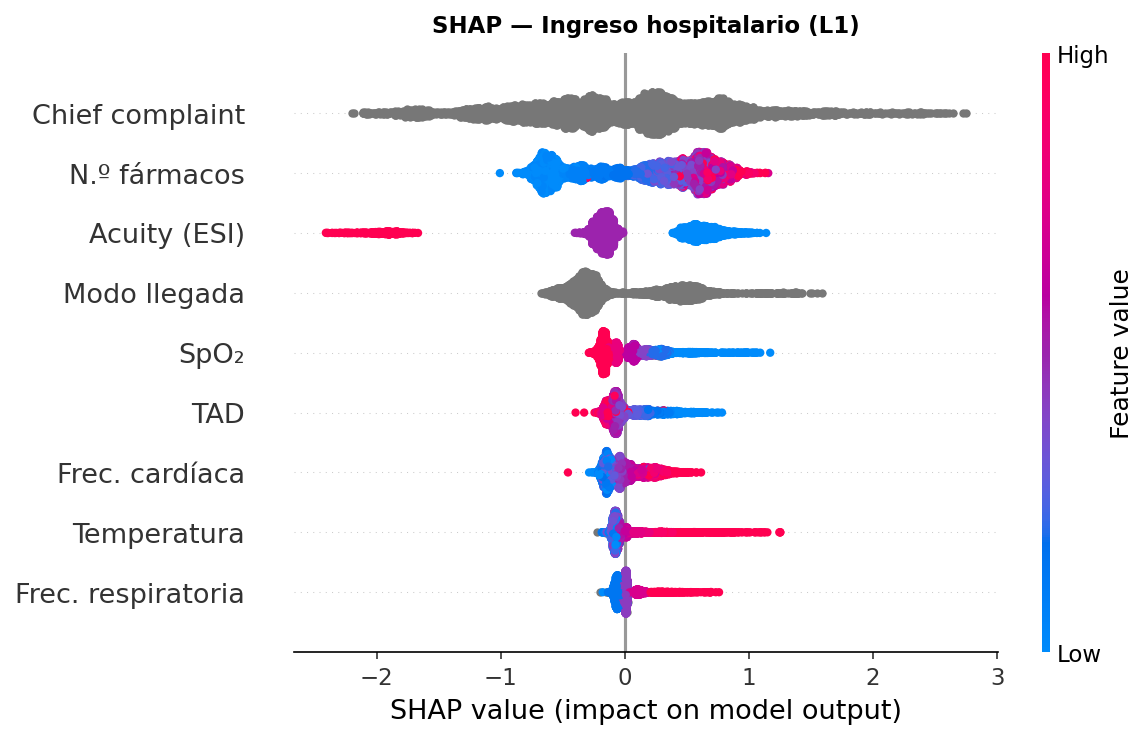

shap_summary_L1.png guardado


C:\Users\cuent\AppData\Local\Temp\ipykernel_3592\2670993593.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample,


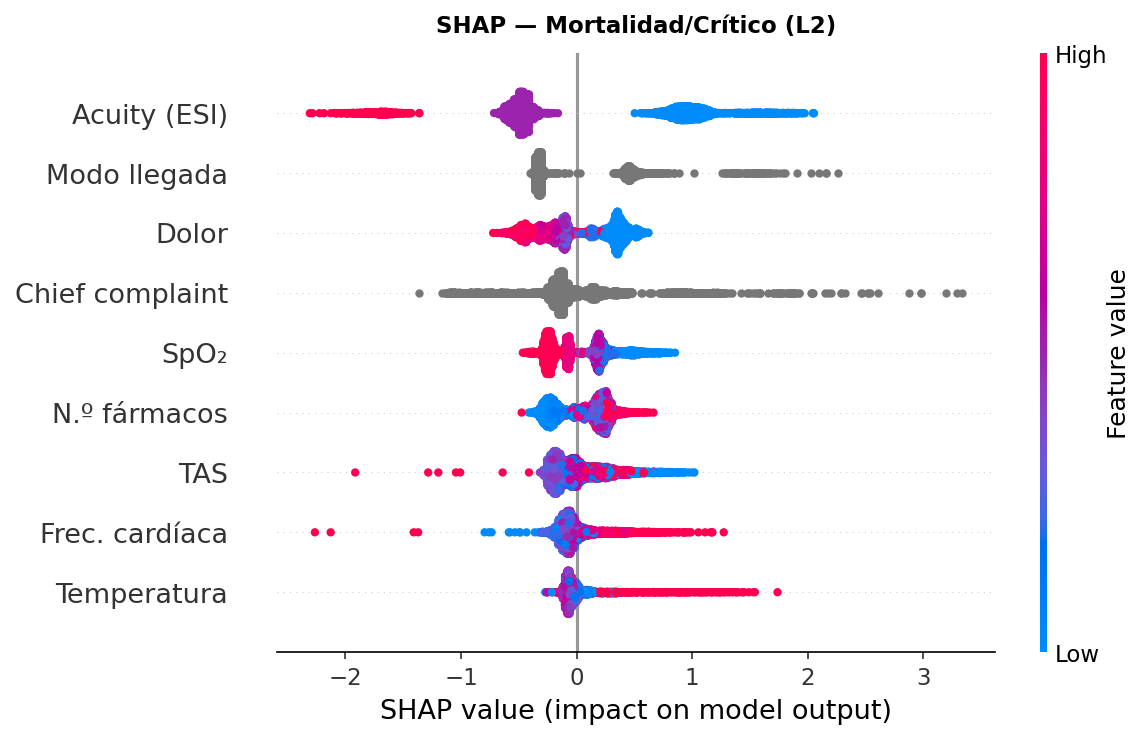

shap_summary_L2.png guardado


C:\Users\cuent\AppData\Local\Temp\ipykernel_3592\2670993593.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample,


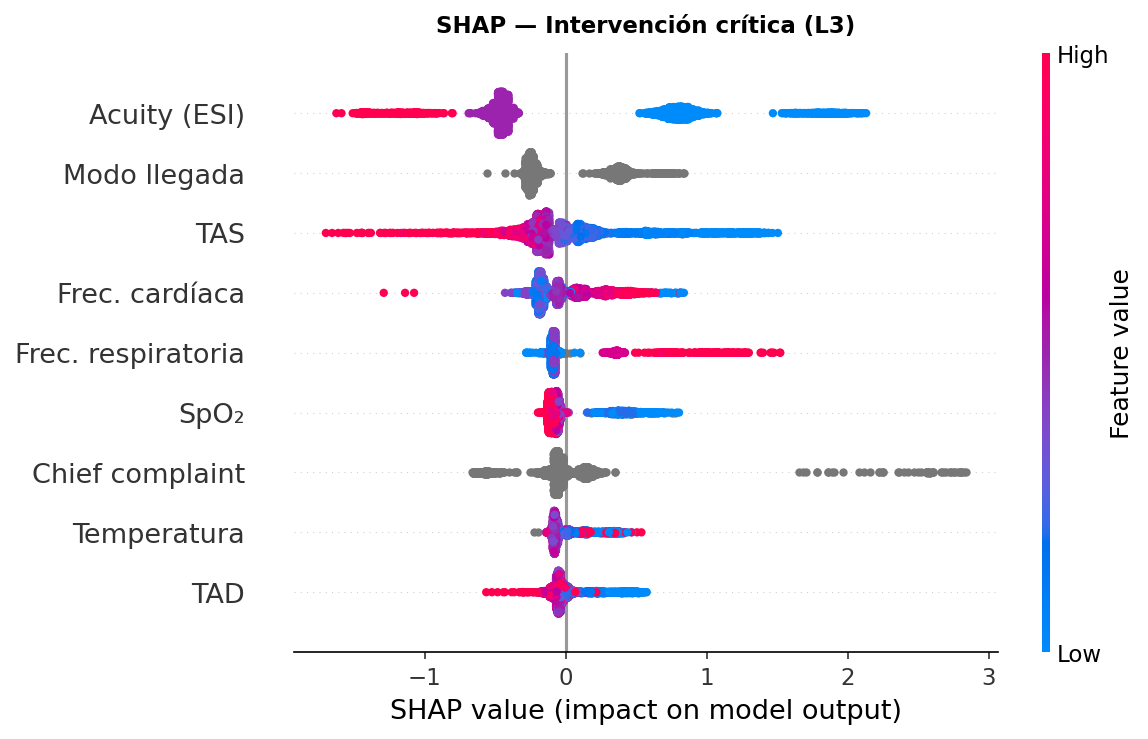

shap_summary_L3.png guardado


In [6]:
for t in TARGETS:
    explainer, shap_values, _ = shap_all[t]
    fig, ax = plt.subplots(figsize=(8, 5))
    shap.summary_plot(shap_values, X_sample,
                      feature_names=FEAT_LABELS_ALL,
                      show=False, plot_size=None, max_display=9)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    plt.title(f'SHAP — {TARGET_NAMES[t]} ({t})', fontsize=11, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig(FIG / f'shap_summary_{t}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'shap_summary_{t}.png guardado')

## 5. Bar charts (importancia media |SHAP|)

Importancia global por feature: media del valor absoluto de SHAP sobre los 5.000 casos. Esta métrica agrega la magnitud de contribución independientemente de su signo, equivalente a la importancia de permutación pero con garantías de consistencia.

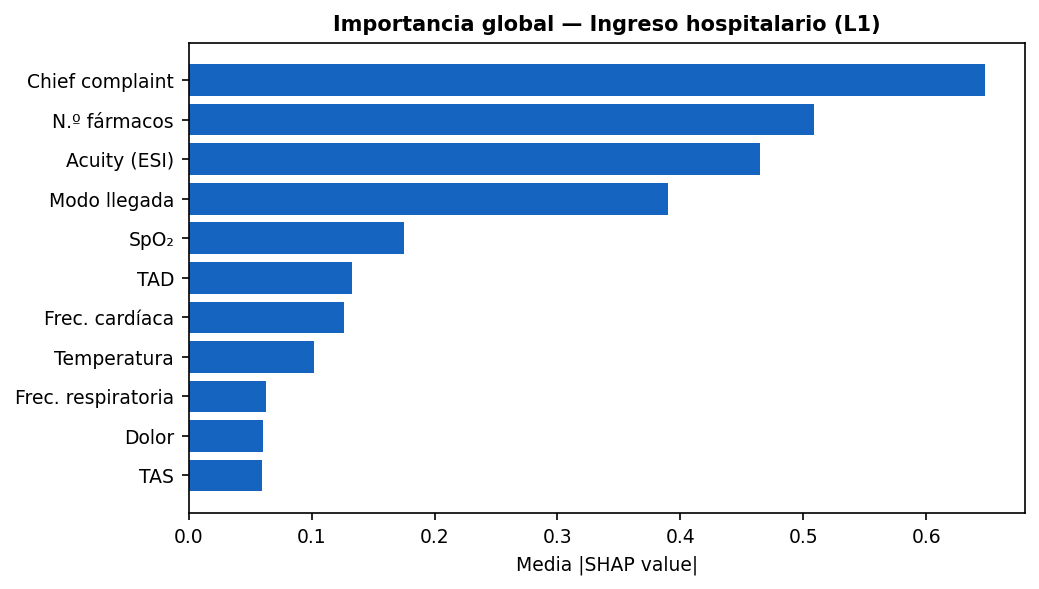

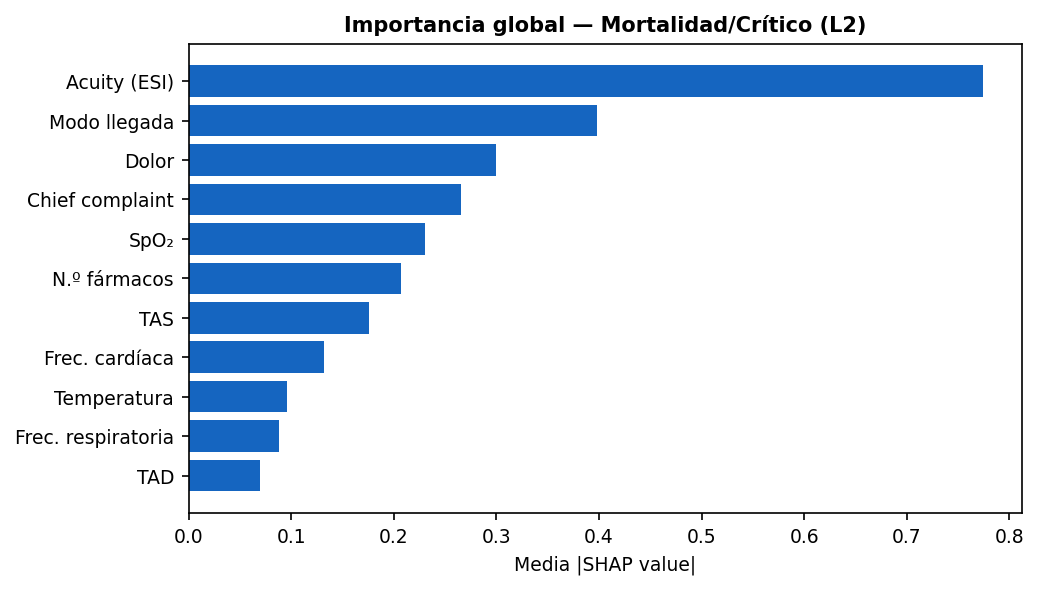

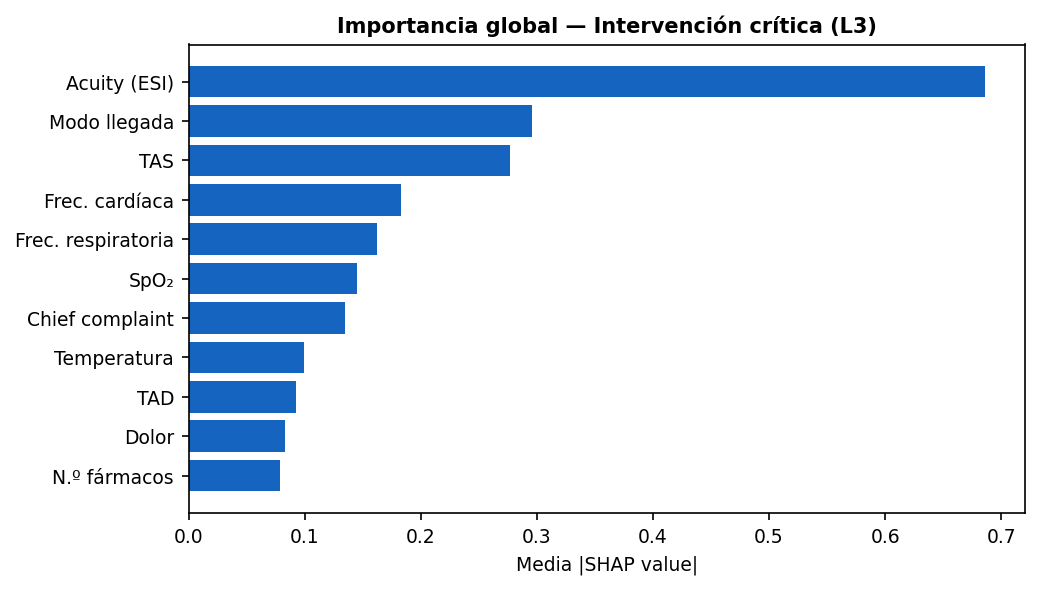

In [7]:
for t in TARGETS:
    sub = df_imp[df_imp.Target == t].copy()
    sub['Label'] = sub['Feature'].map(dict(zip(CB_FEATURES, FEAT_LABELS_ALL)))
    sub = sub.sort_values('mean_abs_SHAP', ascending=True)

    fig, ax = plt.subplots(figsize=(7, 4))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    ax.barh(sub['Label'], sub['mean_abs_SHAP'], color='#1565C0')
    ax.set_xlabel('Media |SHAP value|')
    ax.set_title(f'Importancia global — {TARGET_NAMES[t]} ({t})',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG / f'shap_bar_{t}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Waterfall plots (explicacion local)

Los waterfall plots descomponen la predicción de casos individuales: caso de máximo riesgo (probabilidad más alta) y mínimo riesgo. Permite auditar si las features de mayor contribución son clínicamente coherentes con el estado del paciente.

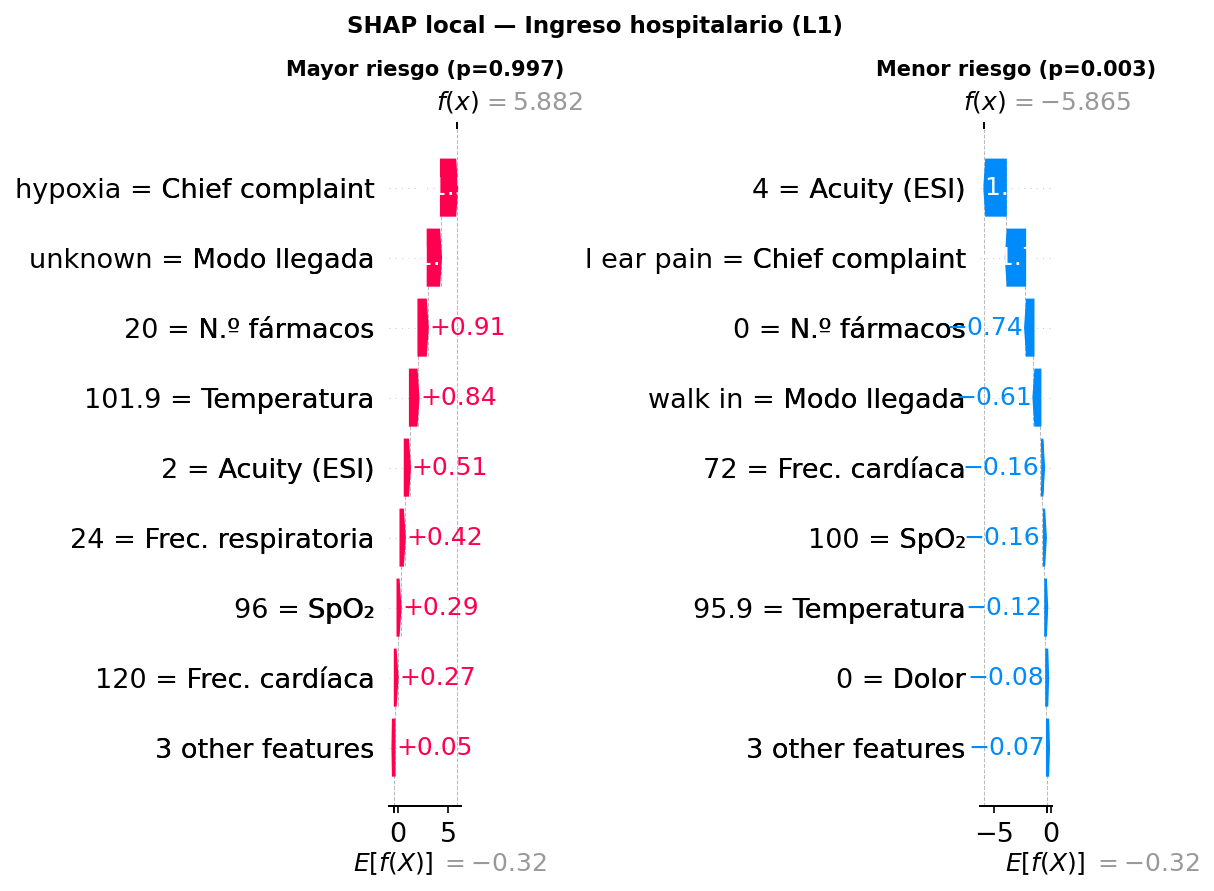

shap_waterfall_L1.png guardado


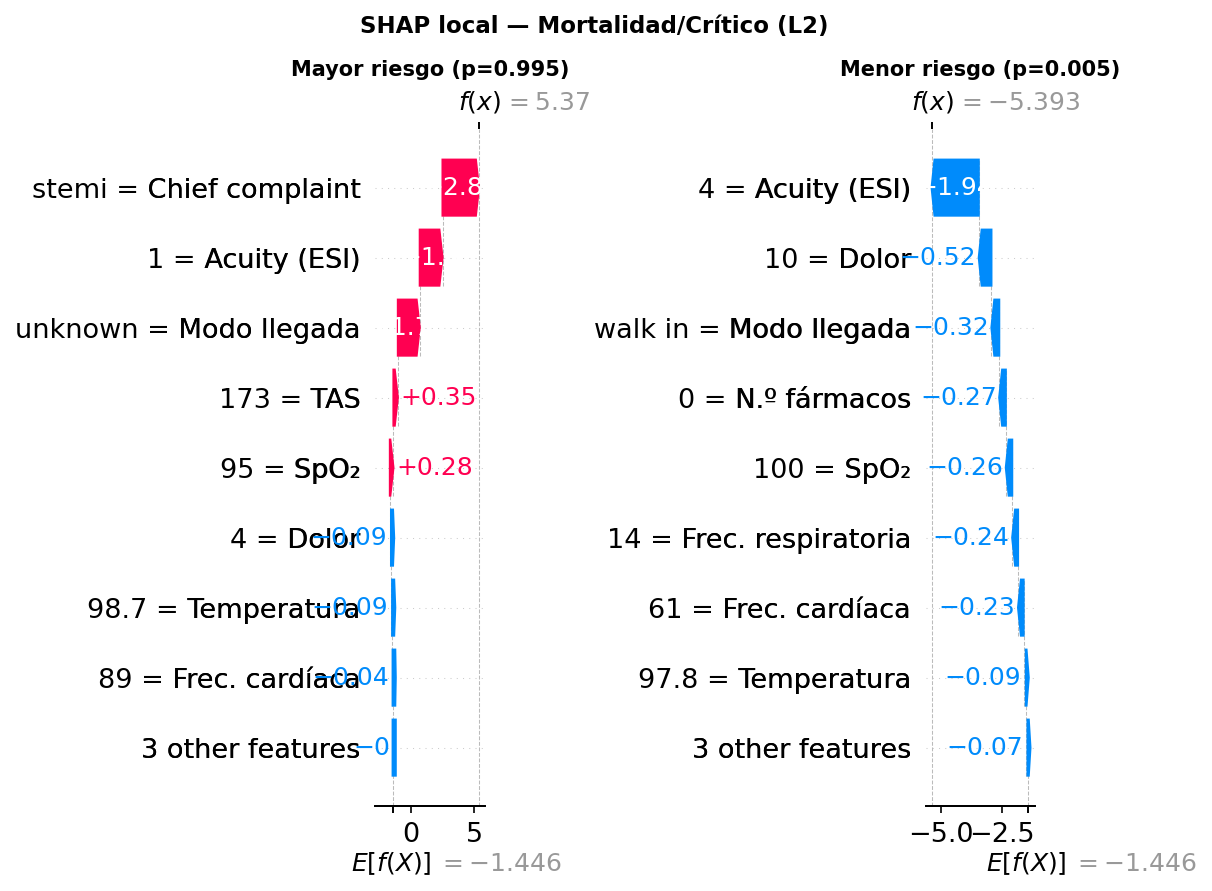

shap_waterfall_L2.png guardado


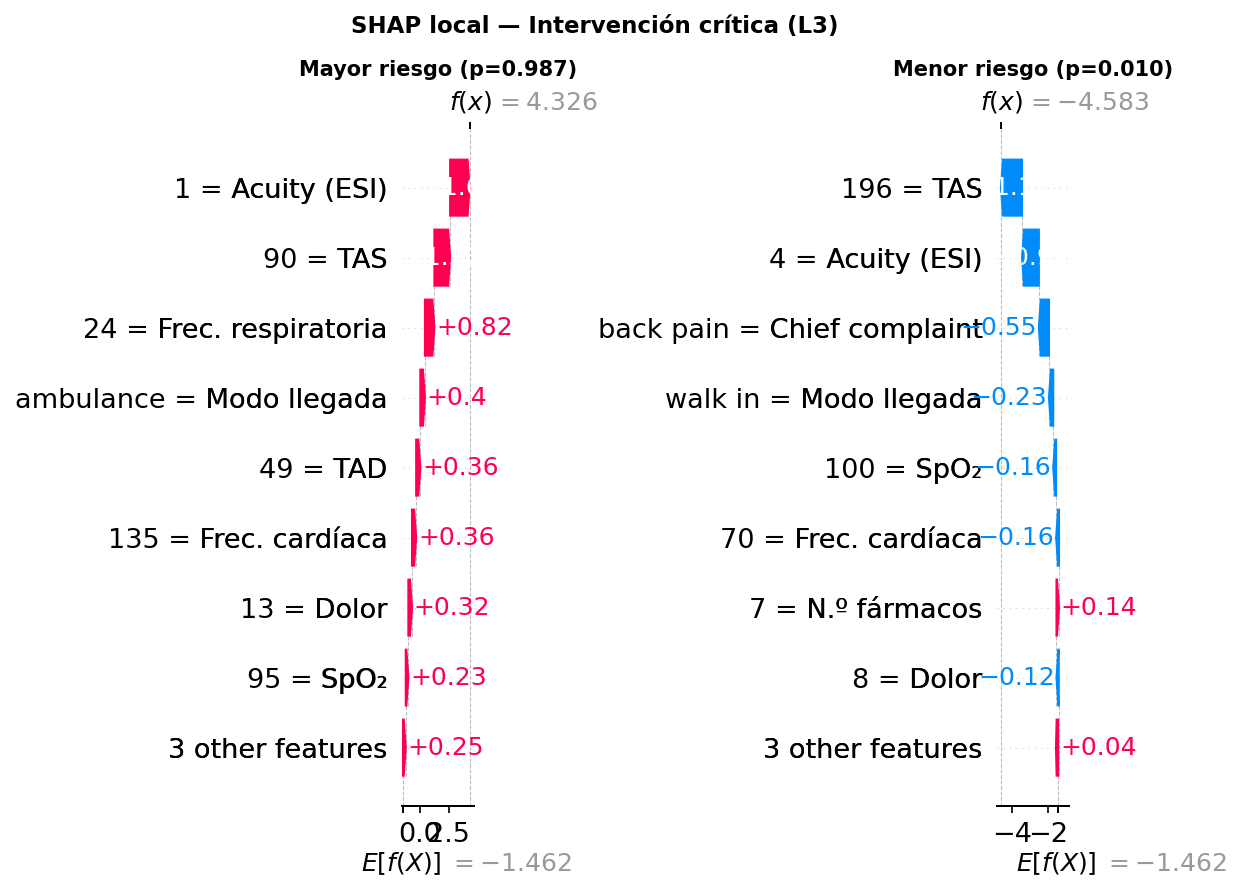

shap_waterfall_L3.png guardado


In [8]:
for t in TARGETS:
    explainer, shap_values, probs = shap_all[t]
    idx_high = int(np.argmax(probs))
    idx_low  = int(np.argmin(probs))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('white')
    for ax, case_idx, label in [(axes[0], idx_high, 'Mayor riesgo'),
                                 (axes[1], idx_low,  'Menor riesgo')]:
        plt.sca(ax)
        shap.waterfall_plot(
            shap.Explanation(
                values        = shap_values[case_idx],
                base_values   = explainer.expected_value,
                data          = X_sample.iloc[case_idx].values,
                feature_names = FEAT_LABELS_ALL,
            ),
            show=False, max_display=9,
        )
        ax.set_facecolor('white')
        ax.tick_params(colors='black')
        ax.xaxis.label.set_color('black')
        ax.yaxis.label.set_color('black')
        ax.set_title(f'{label} (p={probs[case_idx]:.3f})', fontsize=10, fontweight='bold')

    plt.suptitle(f'SHAP local — {TARGET_NAMES[t]} ({t})', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG / f'shap_waterfall_{t}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'shap_waterfall_{t}.png guardado')

## 7. Guardar tabla de importancia

Exportación de `shap_importance.csv` con la media de |SHAP| por feature y target. Este fichero se usa como fuente de datos para la tabla de importancia del manuscrito.

In [9]:
df_imp.to_csv(TAB / 'shap_importance.csv', index=False)
print(f'shap_importance.csv guardado')
pivot

shap_importance.csv guardado


Target,L1,L2,L3
Feature,,,
Acuity (ESI),0.4649,0.7739,0.6858
Modo llegada,0.3898,0.3982,0.2961
Dolor,0.0602,0.2991,0.0830
Chief complaint,0.6475,0.2658,0.1346
SpO₂,0.1748,0.2301,0.1447
N.º fármacos,0.5087,0.2065,0.0789
TAS,0.0592,0.1758,0.2770
Frec. cardíaca,0.1266,0.1317,0.1831
Temperatura,0.1022,0.0961,0.0989
